In [1]:
import pandas as pd
import numpy as np

In [2]:
class Option:
    def __init__(self, strike: float, premium: float, expiry: str):
        self.strike = strike
        self.premium = premium
        self.expiry = expiry
        self.spot_price = None

    def insert_spot(self, spot_price: float):
        self.spot_price = spot_price
    
    def short_call(self):
        # Payoff for short call: premium received - intrinsic value of the option
        intrinsic_value = np.maximum(0, self.spot_price - self.strike)
        return self.premium - intrinsic_value
    
    def long_call(self):
        # Payoff for long call: intrinsic value - premium paid
        intrinsic_value = np.maximum(0, self.spot_price - self.strike)
        return intrinsic_value - self.premium
    
    def short_put(self):
        # Payoff for short put: premium received - intrinsic value of the option
        intrinsic_value = np.maximum(0, self.strike - self.spot_price)
        return self.premium - intrinsic_value
    
    def long_put(self):
        # Payoff for long put: intrinsic value - premium paid
        intrinsic_value = np.maximum(0, self.strike - self.spot_price)
        return intrinsic_value - self.premium


class IronCondor:
    def __init__(self, direction: str, strikes: dict, premiums: dict, expiry: str):
        """
        Initialize the Iron Condor strategy with strikes and premiums for the options.
        
        direction: long, (short) Iron Condor
        1. Short (Long) 1 OTM Put (strike 1)
        2. Long (Short) 1 close to ATM Put (strike 2)
        3. Long (Short) 1 close to ATM Call (strike 3)
        4. Short (Long) 1 OTM Call (strike 4)        

        strikes: a dictionary of strikes for the 4 options (strike1 to strike4)
        premiums: a dictionary of premiums for the 4 options (premium1 to premium4)
        expiry: expiration date of the options
        """
        self.premiums = premiums
        self.direction = direction
        self.short_put_option = Option(strikes['strike1'], premiums['premium1'], expiry)
        self.long_put_option = Option(strikes['strike2'], premiums['premium2'], expiry)
        self.long_call_option = Option(strikes['strike3'], premiums['premium3'], expiry)
        self.short_call_option = Option(strikes['strike4'], premiums['premium4'], expiry)

    def initial_cashflow(self):
        """
        Calculate the initial cashflow of the Iron Condor strategy.
        """
        if self.direction == "long":
            initial_cashflow = self.premiums['premium1'] - self.premiums['premium2'] - self.premiums['premium3'] + self.premiums['premium4']
        elif self.direction == "short":
            initial_cashflow = -self.premiums['premium1'] + self.premiums['premium2'] + self.premiums['premium3'] - self.premiums['premium4']
        
        return initial_cashflow

    def insert_spot(self, spot_price: float):
        """
        Insert the current spot price for all the options in the Iron Condor strategy.
        """
        self.short_put_option.insert_spot(spot_price)
        self.long_put_option.insert_spot(spot_price)
        self.long_call_option.insert_spot(spot_price)
        self.short_call_option.insert_spot(spot_price)
    
    def payoff(self):
        """
        Calculate the total payoff (profit or loss) of the Iron Condor strategy.
        
        direction: 'long' for long Iron Condor, 'short' for short Iron Condor
        """
        if self.direction == "long":
            short_put = self.short_put_option.short_put()
            long_put = self.long_put_option.long_put()
            long_call = self.long_call_option.long_call()
            short_call = self.short_call_option.short_call()
            total_payoff = short_put + long_put + long_call + short_call
        elif self.direction == "short":
            long_put = -self.long_put_option.long_put()
            short_put = -self.short_put_option.short_put()
            short_call = -self.short_call_option.short_call()
            long_call = -self.long_call_option.long_call()
            total_payoff = long_put + short_put + short_call + long_call
        
        return float(total_payoff)

class OptionsBacktester:
    def __init__(self,
                 signal_df: pd.DataFrame,
                 spot_price_df: pd.DataFrame,
                 options_df: pd.DataFrame,
                 upper_threshold: float,
                 lower_threshold: float,
                 option_type: str,
                 dynamic_option_strategy: bool = False,
                 dynamic_strike: bool = False,):
        self.signal_df = signal_df
        self.signal_df.columns = ["signal"]
        self.spot_price_df = spot_price_df
        self.options_df = options_df
        self.upper_threshold = upper_threshold
        self.lower_threshold = lower_threshold
        self.option_type = option_type
        self.dynamic_option_strategy = dynamic_option_strategy
        self.dynamic_strike = dynamic_strike

        self.comb_df = pd.concat([self.signal_df, self.spot_price_df.shift(), self.options_df.shift()], axis=1)
        self.comb_df["action"] = np.where(self.comb_df["signal"] > self.upper_threshold, 1, np.where(self.comb_df["signal"] < self.lower_threshold, -1, 0))

    def long_short_vol_df(self):
        self.trading_df = {}
        for index, row in self.comb_df.iterrows():
            if row["action"] != 0:
                self.trading_df[index] = self.comb_df.loc[index]

In [46]:
strikes = {
    'strike1': 95,
    'strike2': 100,
    'strike3': 105,
    'strike4': 110 
}

premiums = {
    'premium1': 0.7,
    'premium2': 2.1,
    'premium3': 2.35,
    'premium4': 0.95 
}

expiry = "2024-12-31"

ironcondor = IronCondor(direction="short", strikes=strikes, premiums=premiums, expiry=expiry)
print(ironcondor.initial_cashflow())
ironcondor.insert_spot(90)
ironcondor.payoff()

2.8


-2.2000000000000006

## Code to filter down the options data to only rows where strike matches spot

In [4]:
# upper_threshold = 1
# lower_threshold = -1

# aapl_vrp = pd.read_csv("data/AAPL_vrp_standardised.csv", parse_dates=True, index_col=0)

# aapl = pd.read_hdf("data/all_tickers_time_series.hf5", key="AAPL").drop_duplicates().set_index("date")

# aapl.index = pd.to_datetime(aapl.index)

# options_data = pd.read_hdf("data/all_options_data.h5", key="AAPL").set_index("date")
# options_data['exdate'] = pd.to_datetime(options_data['exdate'])
# options_data.index = pd.to_datetime(options_data.index)


# # options_data_filtered = pd.DataFrame()
# options_data['price'] = aapl["prc"]
# options_data["strike_price"] = options_data["strike_price"] / 1000
# # for date in options_data.index.unique():
# #     if options_data.loc[date]["exdate"].nunique() > 1:
# #         options_data_filtered = pd.concat([options_data_filtered, options_data.loc[date].query("exdate == exdate.min()")], axis=0)


# options_data_filtered = options_data.groupby("date").apply(lambda x: x.query("exdate == exdate.min()")).reset_index(level=0, drop=True)

# # options_data_filtered["strike_minus_price"] = np.abs(options_data_filtered["strike_price"] - options_data_filtered["price"])
# # new_df = options_data_filtered.groupby("date").apply(lambda x: x.query("strike_minus_price == strike_minus_price.min()")).reset_index(level=0, drop=True)
# # date_counts = new_df.index.value_counts()
# # def filter_max_open_interest(x):
# #     if len(x) >= 2:
# #         return x.query("open_interest == open_interest.max()")
# #     return x 

# # new_new_df = new_df.groupby(['date', 'cp_flag']).apply(filter_max_open_interest).reset_index(level=[0, 1], drop=True)

# # comb_df = pd.concat([new_new_df, aapl_vrp], axis=1) # the above block is only used if i want to filter the options data for strike close to spot
# comb_df = pd.concat([options_data_filtered, aapl_vrp], axis=1)
# comb_df = comb_df.dropna()
# comb_df["action"] = np.where(comb_df["vrp_standardised"] > upper_threshold, 1, np.where(comb_df["vrp_standardised"] < lower_threshold, -1, 0))

In [5]:
day_map = {0: "Monday", 1: "Tuesday", 2: "Wednesday", 3: "Thursday", 4: "Friday", 5: "Saturday", 6: "Sunday"}

xlu_options = pd.read_hdf("data/etf_options_data.hf5", key="XLU")
xlu_options = xlu_options.set_index("date")
xlu_options["strike_price"] = xlu_options["strike_price"] / 1000
xlu_filtered_options = xlu_options.groupby("date").apply(lambda x: x.query("exdate == exdate.min()")).reset_index(level=0, drop=True)
xlu_filtered_options["day"] = xlu_filtered_options.index.weekday.map(day_map)
xlu_filtered_options["ex_day"] = xlu_filtered_options["exdate"].dt.weekday.map(day_map)
xlu_filtered_options

,ticker,exdate,cp_flag,strike_price,best_bid,best_offer,open_interest,impl_volatility,delta,gamma,theta,vega,volume,day,ex_day
date,,,,,,,,,,,,,,,
2000-01-10,XLU,2000-01-22,C,31.0,0.0000,0.1250,0.0,0.423886,0.068868,0.062562,-4.271427,0.662345,0.0,Monday,Saturday
2000-01-10,XLU,2000-01-22,P,29.0,1.4375,1.6250,0.0,0.271660,-0.839551,0.179317,-4.941929,1.211415,0.0,Monday,Saturday
2000-01-10,XLU,2000-01-22,P,30.0,2.3750,2.6250,0.0,0.353248,-0.899561,0.099878,-4.593377,0.872273,0.0,Monday,Saturday
2000-01-10,XLU,2000-01-22,C,28.0,0.0625,0.1875,0.0,0.143454,0.283783,0.471890,-3.686701,1.692336,0.0,Monday,Saturday
2000-01-10,XLU,2000-01-22,C,27.0,0.5625,0.7500,0.0,0.140491,0.799844,0.397932,-2.952004,1.393989,0.0,Monday,Saturday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-31,XLU,2023-09-01,P,60.5,0.0000,0.0200,17.0,0.379238,-0.021437,0.041134,-11.656990,0.169143,0.0,Thursday,Friday
2023-08-31,XLU,2023-09-01,P,61.0,0.0000,0.0200,103.0,0.312279,-0.025489,0.057789,-11.088450,0.195682,5.0,Thursday,Friday
2023-08-31,XLU,2023-09-01,P,61.5,0.0000,0.0200,100.0,0.243774,-0.031731,0.088816,-10.360040,0.235267,1.0,Thursday,Friday


## XLU

### Pulling data

In [6]:
xlu_pred = pd.read_csv("data/xlu_pred.csv", parse_dates=True, index_col=0).rename(columns={"0": "Rolling Pred"})
xlu_iv = pd.read_csv("data/XLU_IV.csv", parse_dates=True, index_col=0)
xlu_vrp = (xlu_iv["Average IV"] - xlu_pred["Rolling Pred"]).dropna()

<Axes: >

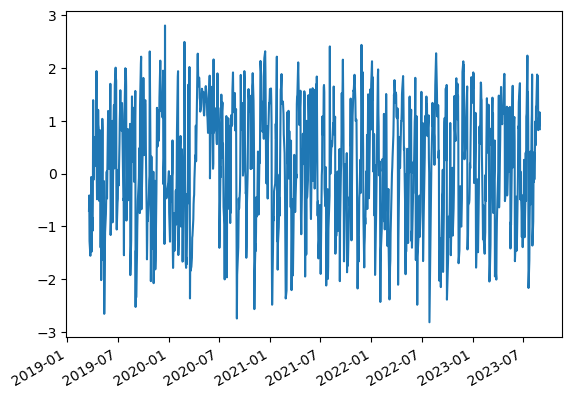

In [7]:
from data_wrangling import rolling_z_score
xlu_vrp_standardised = rolling_z_score(xlu_vrp, window=10)
xlu_vrp_standardised.plot()

### Merge VRP data with options data

In [42]:
upper_threshold = 1.5
lower_threshold = -1.5

xlu_filtered_options["vrp"] = xlu_vrp_standardised
xlu_time_series = pd.read_hdf("data/etf_series.hf5", key="XLU")
xlu_time_series["day"] = xlu_time_series.index.weekday
xlu_time_series["vrp"] = xlu_vrp_standardised
xlu_time_series["signal"] = np.where(xlu_time_series["vrp"] > upper_threshold, 1, np.where(xlu_time_series["vrp"] < lower_threshold, -1, 0))
xlu_time_series["action"] = np.where((xlu_time_series["signal"] == 1)  & (xlu_time_series.index.weekday != 4), 1, 
                                     np.where((xlu_time_series["signal"] == -1) & (xlu_time_series.index.weekday != 4), -1, 
                                              0))
xlu_time_series.dropna(inplace=True)
xlu_time_series

def ensure_weekly_action(df):
    last_action = 0
    last_week = -1

    for i in range(len(df)):
        current_week = df.index[i].isocalendar()[1]  # Get the week number
        current_day = df["day"].iloc[i]

        if current_week != last_week:  # Reset at the start of a new week
            last_action = 0
            last_week = current_week

        if last_action != 0 and df["action"].iloc[i] != 0:
            # If an action has already occurred this week, set to 0
            df.at[df.index[i], "action"] = 0
        elif df["action"].iloc[i] != 0:
            # If this is the first action of the week, update last_action
            last_action = df["action"].iloc[i]

    return df

xlu_time_series = ensure_weekly_action(xlu_time_series)
xlu_time_series["action"] = xlu_time_series["action"].shift()
xlu_time_series

,Open,High,Low,Close,Adj Close,Volume,day,vrp,signal,action
Date,,,,,,,,,,
2019-03-20,57.419998,57.919998,57.169998,57.459999,48.255390,18880500,2,-0.707107,0,NaN
2019-03-21,57.500000,58.189999,57.410000,58.070000,48.767689,15371800,3,-0.413402,0,0.0
2019-03-22,58.290001,58.900002,58.070000,58.490002,49.120403,20452500,4,-1.278116,0,0.0
2019-03-25,58.540001,58.720001,58.299999,58.540001,49.162395,13763000,0,-1.555630,-1,0.0
2019-03-26,58.570000,59.000000,58.490002,58.959999,49.515114,15699700,1,-1.118795,0,-1.0
...,...,...,...,...,...,...,...,...,...,...
2023-08-25,63.240002,63.950001,63.200001,63.630001,61.106991,12490500,4,0.823560,0,0.0
2023-08-28,63.740002,64.089996,63.490002,63.619999,61.097385,8663200,0,1.091036,0,0.0
2023-08-29,63.700001,64.050003,63.439999,63.860001,61.327869,11873100,1,0.908154,0,0.0


In [54]:
def myround(x, base=5):
    return base * round(x/base)


ironcondor_tracker = {}

for index, row in xlu_time_series.iterrows():
    if row["action"] != 0:
        spot_open = row["Open"]

        strikes = {
        "strike1": myround(spot_open * 0.9, base=5),
        "strike2": myround(spot_open * 0.95, base=5),
        "strike3": myround(spot_open * 1.05, base=5),
        "strike4": myround(spot_open * 1.1, base=5)
    }
        
        if row["action"] == 1:
            direction = "long"
            premiums = {
                "premium1": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike1"]) & 
                    (xlu_filtered_options["cp_flag"] == 'P'), "best_bid"
                ],
                "premium2": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike2"]) & 
                    (xlu_filtered_options["cp_flag"] == 'P'), "best_offer"
                ],
                "premium3": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike3"]) & 
                    (xlu_filtered_options["cp_flag"] == 'C'), "best_offer"
                ],
                "premium4": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike4"]) & 
                    (xlu_filtered_options["cp_flag"] == 'C'), "best_bid"
                ]
            }
        elif row["action"] == -1:
            direction = "short"
            premiums = {
                "premium1": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike1"]) & 
                    (xlu_filtered_options["cp_flag"] == 'P'), "best_offer"
                ],
                "premium2": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike2"]) & 
                    (xlu_filtered_options["cp_flag"] == 'P'), "best_bid"
                ],
                "premium3": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike3"]) & 
                    (xlu_filtered_options["cp_flag"] == 'C'), "best_bid"
                ],
                "premium4": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike4"]) & 
                    (xlu_filtered_options["cp_flag"] == 'C'), "best_offer"
                ]
            }
        
        expiry = xlu_filtered_options.loc[index]["exdate"].min()

        ironcondor = IronCondor(direction=direction, strikes=strikes, premiums=premiums, expiry=expiry)
        ironcondor_tracker[index] = (ironcondor, expiry)

In [55]:
pnl_list = []
for date, (ironcondor, expiry) in ironcondor_tracker.items():
    try:
        ironcondor.insert_spot(xlu_time_series.at[expiry, "Close"])
        pnl_list.append(ironcondor.payoff())
    except KeyError:
        continue

C:\Users\Gavin\AppData\Local\Temp\ipykernel_23352\1377766752.py:93: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(total_payoff)


<Axes: >

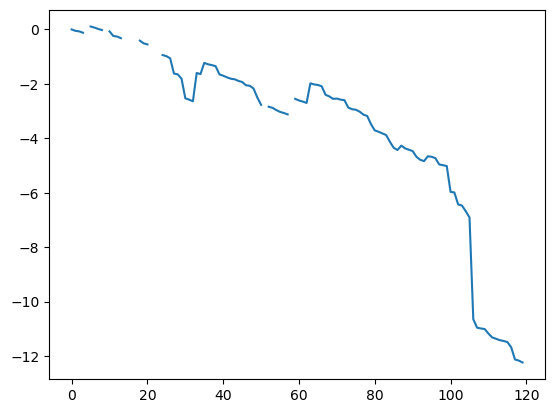

In [56]:
pd.Series(pnl_list).cumsum().plot()